In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import decode_predictions
from tensorflow.keras.preprocessing import image

print(tf.__version__)
print("All Imports Successful")

2.21.0
All Imports Successful


Model Loaded Successfully!


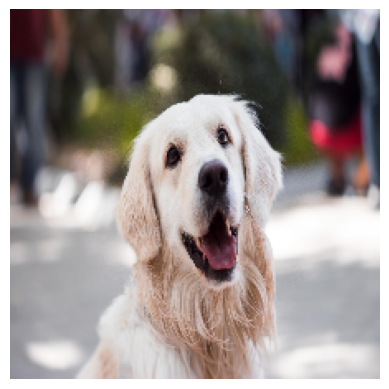

(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
golden_retriever : 52.07%
Great_Pyrenees : 11.71%
kuvasz : 11.13%
Labrador_retriever : 10.58%
English_setter : 0.46%


In [8]:
#load the pre-trained model
model = MobileNetV2(weights="imagenet")

print("Model Loaded Successfully!")
#load iamge
img_path = "images/dog.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

plt.imshow(img)
plt.axis("off")
plt.show()
#converting image into array
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

print(img_array.shape)
#prediction
prediction = model.predict(img_array)
#decode the prediction
results = decode_predictions(prediction, top=5)[0]
#display results
for _, label, confidence in results:
    print(f"{label} : {confidence*100:.2f}%")

#creating the resuable function
def predict_image(img_path):

    img = image.load_img(img_path, target_size=(224,224))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)

    results = decode_predictions(prediction, top=5)[0]

    print("\nTop Predictions:\n")

    for _, label, confidence in results:
        print(f"{label} : {confidence*100:.2f}%")